# Using Albumentations to augment keypoints

In this notebook we will show how to apply Albumentations to the keypoint augmentation problem. Please refer to [A list of transforms and their supported targets](https://albumentations.ai/docs/reference/supported-targets-by-transform/#spatial-level-dual-transforms) to see which spatial-level augmentations support keypoints. You can use any pixel-level augmentation to an image with keypoints because pixel-level augmentations don't affect keypoints.

**Note**: by default, augmentations that work with keypoints don't change keypoints' labels after transformation. If keypoints' labels are side-specific, that may pose a problem. For example, if you have a keypoint named `left arm` and apply a HorizontalFlip augmentation, you will get a keypoint with the same `left arm` label, but it will now look like a `right arm` keypoint. See a picture at the end of [this article](https://albumentations.ai/docs/3-basic-usage/keypoint-augmentations/) for a visual example.

If you work with such type of keypoints, consider using SymmetricKeypoints augmentations from [albumentations-experimental](https://github.com/albumentations-team/albumentations_experimental#spatial-level-transforms) that are created precisely to handle that case.

### Import the required libraries

In [ ]:
import random

import albumentations as A
import cv2
from matplotlib import pyplot as plt

### Define a function to visualize keypoints on an image

In [ ]:
KEYPOINT_COLOR = (0, 255, 0)  # Green


def vis_keypoints(image, keypoints, color=KEYPOINT_COLOR, diameter=15):
    image = image.copy()

    for x, y in keypoints:
        cv2.circle(image, (int(x), int(y)), diameter, color, -1)

    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.imshow(image)

#### Get an image and annotations for it

In [ ]:
image = cv2.imread("images/keypoints_image.jpg", cv2.IMREAD_COLOR_RGB)

#### Define keypoints

We will use the `xy` format for keypoints' coordinates. Each keypoint is defined with two coordinates, `x` is the position on the x-axis, and `y` is the position on the y-axis. Please refer to this article with the detailed description of formats for keypoints' coordinates - <a href='https://albumentations.ai/docs/3-basic-usage/keypoint-augmentations/' target='_blank'>https://albumentations.ai/docs/3-basic-usage/keypoint-augmentations/</a>

In [ ]:
keypoints = [
    (100, 100),
    (720, 410),
    (1100, 400),
    (1700, 30),
    (300, 650),
    (1570, 590),
    (560, 800),
    (1300, 750),
    (900, 1000),
    (910, 780),
    (670, 670),
    (830, 670),
    (1000, 670),
    (1150, 670),
    (820, 900),
    (1000, 900),
]

### Visualize the original image with keypoints

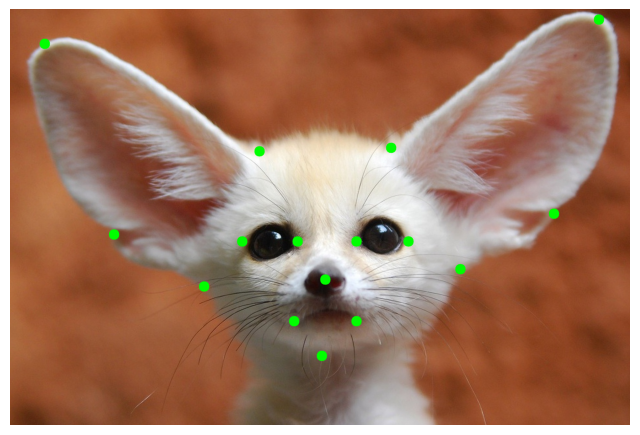

In [ ]:
vis_keypoints(image, keypoints)

### Define a simple augmentation pipeline

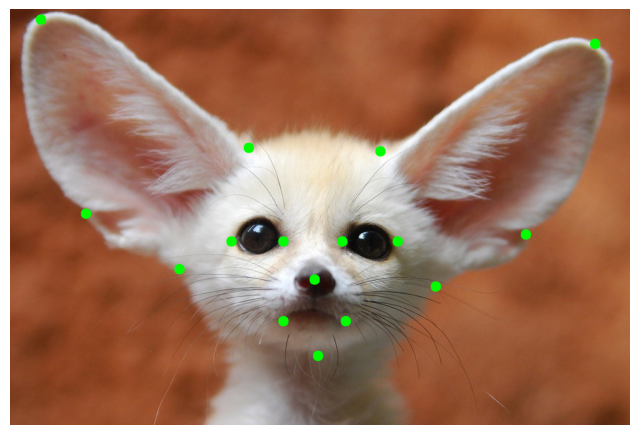

In [ ]:
transform = A.Compose(
    [A.HorizontalFlip(p=1)],
    keypoint_params=A.KeypointParams(format="xy"),
)
transformed = transform(image=image, keypoints=keypoints)
vis_keypoints(transformed["image"], transformed["keypoints"])

### A few more examples of augmentation pipelines

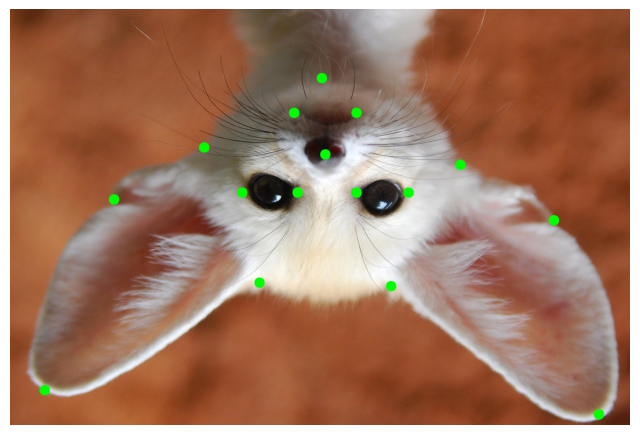

In [ ]:
transform = A.Compose(
    [A.VerticalFlip(p=1)],
    keypoint_params=A.KeypointParams(format="xy"),
)
transformed = transform(image=image, keypoints=keypoints)
vis_keypoints(transformed["image"], transformed["keypoints"])

We fix the random seed for visualization purposes, so the augmentation will always produce the same result. In a real computer vision pipeline, you shouldn't fix the random seed before applying a transform to the image because, in that case, the pipeline will always output the same image. The purpose of image augmentation is to use different transformations each time.

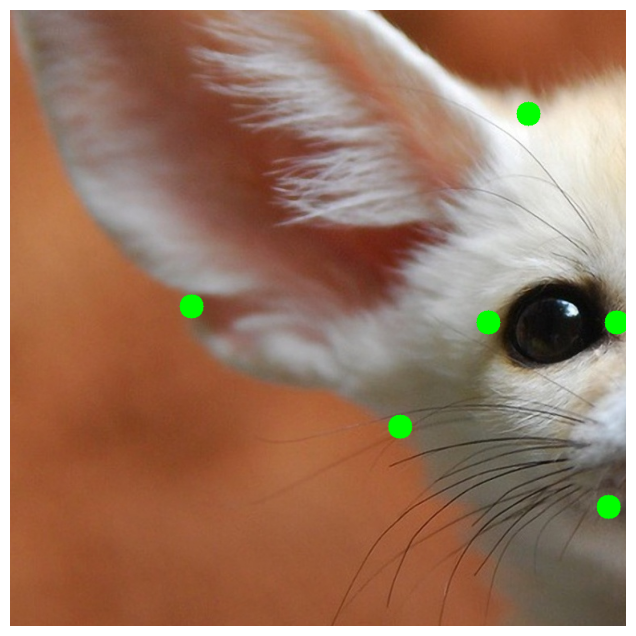

In [ ]:
random.seed(7)
transform = A.Compose(
    [A.RandomCrop(width=768, height=768, p=1)],
    keypoint_params=A.KeypointParams(format="xy"),
)
transformed = transform(image=image, keypoints=keypoints)
vis_keypoints(transformed["image"], transformed["keypoints"])

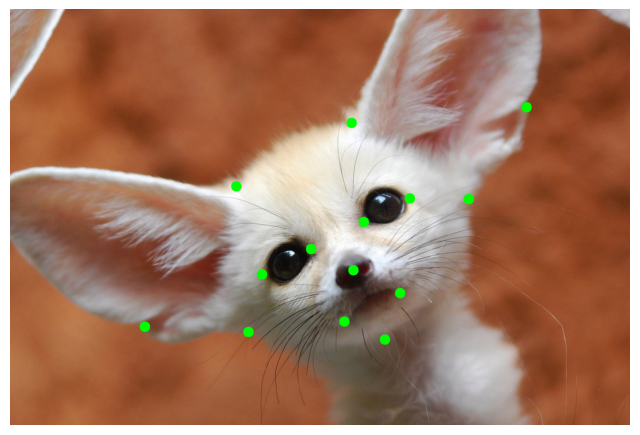

In [ ]:
random.seed(7)
transform = A.Compose(
    [A.Rotate(p=0.5)],
    keypoint_params=A.KeypointParams(format="xy"),
)
transformed = transform(image=image, keypoints=keypoints)
vis_keypoints(transformed["image"], transformed["keypoints"])

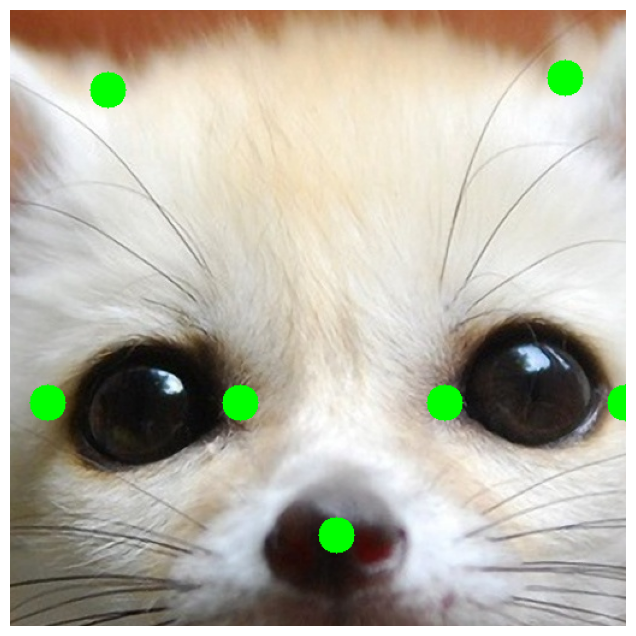

In [ ]:
transform = A.Compose(
    [A.CenterCrop(height=512, width=512, p=1)],
    keypoint_params=A.KeypointParams(format="xy"),
)
transformed = transform(image=image, keypoints=keypoints)
vis_keypoints(transformed["image"], transformed["keypoints"])

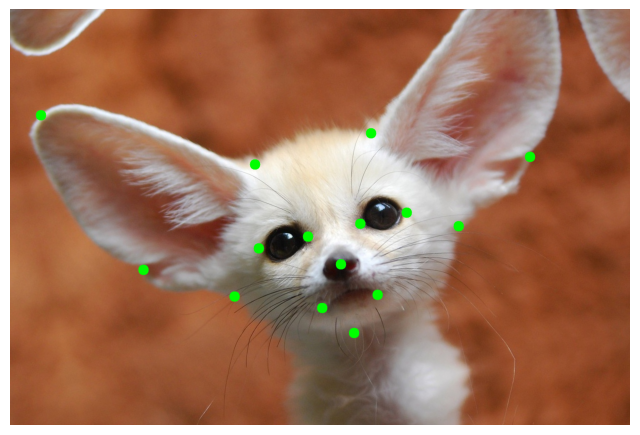

In [ ]:
random.seed(7)
transform = A.Compose(
    [A.ShiftScaleRotate(p=0.5)],
    keypoint_params=A.KeypointParams(format="xy"),
)
transformed = transform(image=image, keypoints=keypoints)
vis_keypoints(transformed["image"], transformed["keypoints"])

### An example of complex augmentation pipeline

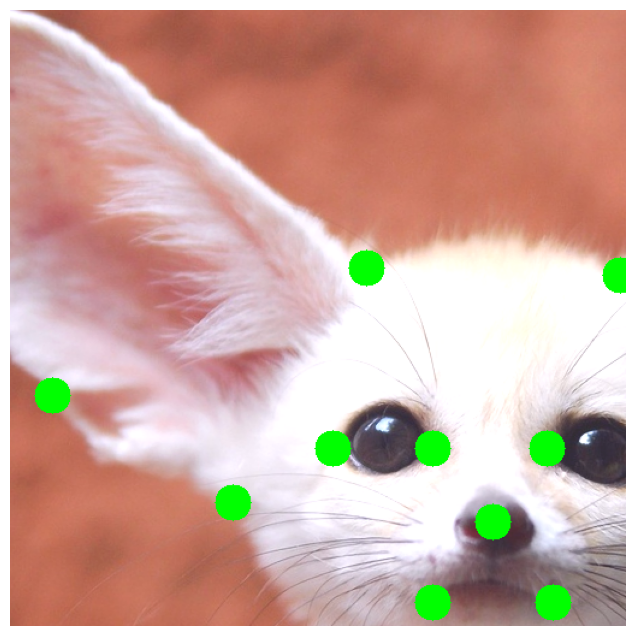

In [ ]:
random.seed(7)
transform = A.Compose(
    [
        A.RandomSizedCrop(min_max_height=(256, 1025), height=512, width=512, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.OneOf(
            [
                A.HueSaturationValue(p=0.5),
                A.RGBShift(p=0.7),
            ],
            p=1,
        ),
        A.RandomBrightnessContrast(p=0.5),
    ],
    keypoint_params=A.KeypointParams(format="xy"),
)
transformed = transform(image=image, keypoints=keypoints)
vis_keypoints(transformed["image"], transformed["keypoints"])